# Chapter 2: Manifolds

**Source Span.** `An Introduction to Manifolds.pdf` printed pages `48-85`. Extraction note: pdftotext table-of-contents extraction.

**Chapter Goal.** Build a standalone visual and computational route through this source unit: Topological and smooth manifolds, atlases, smooth maps, quotients, and projective examples.

This notebook uses the source only for structure, terminology, theorem orientation, and page spans. The prose, examples, diagrams, formulas, and checks are original teaching material designed to let the reader inspect the mathematics without keeping the book open. The central idea is to turn the unit into a small laboratory: definitions become data, constructions become diagrams, proof moves become dependency graphs, and formulas become executable invariants.

The unit-specific inspection vocabulary for this pass is: **Topological, Smooth, Atlases, Maps, Quotients, Projective, Examples**. These terms drive the visuals and the final sanity checks rather than serving as decorative labels.


## Visual Storyboard

        1. **Concept dependency map.** A graph connects `Manifolds` to the constructions, invariants, and examples that organize the source span. Inspect which concepts play the role of inputs and which are checks or outputs.
        2. **Model diagram.** A small executable model makes one concrete phenomenon visible for `Manifolds`. The model is deliberately tiny so every point, edge, curve, or matrix can be inspected.
        3. **Invariant table.** The final cells record formulas such as `d(f\circ g)=df\circ dg`, `[X,Y]=XY-YX`, `d^2=0` and store numeric or symbolic checks as JSON.

        ## Library Routing

        | Library | Why it fits this unit | Artifact/check target |
        | --- | --- | --- |
        | SymPy | coordinate identities | `chapter-02-manifolds` artifacts and invariant checks |
| Matplotlib | charts and vector fields | `chapter-02-manifolds` artifacts and invariant checks |
| NetworkX | atlas graphs | `chapter-02-manifolds` artifacts and invariant checks |


In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_json, save_matplotlib

UNIT_KEY = "chapter-02-manifolds"
UNIT_TITLE = "Manifolds"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
HTML = ARTIFACT_ROOT / "html"
print(f"Book root: {BOOK_ROOT}")


Book root: D:\Geometry\An-Introduction-to-Manifolds


## Translation Guide

The source unit is phrased in the language of **An Introduction to Manifolds**. In this notebook, that language is translated into a reproducible computational grammar:

- Definitions are represented by small data structures: matrices, graphs, point configurations, vector fields, or symbolic expressions.
- Theorem hypotheses become visible constraints that can be toggled or checked.
- Examples are not copied from the book; they are compact synthetic models chosen to expose the same ideas.
- Failure modes are included when useful: degenerate points, missing orientation, nonzero residuals, or graphs whose combinatorics break an invariant.

Keep the following formulas nearby as the unit's computational compass: `d(f\circ g)=df\circ dg`, `[X,Y]=XY-YX`, `d^2=0`. The checks below do not prove the chapter, but they keep the notebook honest about the algebraic or geometric invariants it claims to show.

For this specific unit, keep the source-map focus in view: Topological and smooth manifolds, atlases, smooth maps, quotients, and projective examples. The terms Topological, Smooth, Atlases, Maps, Quotients, Projective, Examples should appear in the learner's explanation of the visual artifacts and in the final invariant check.


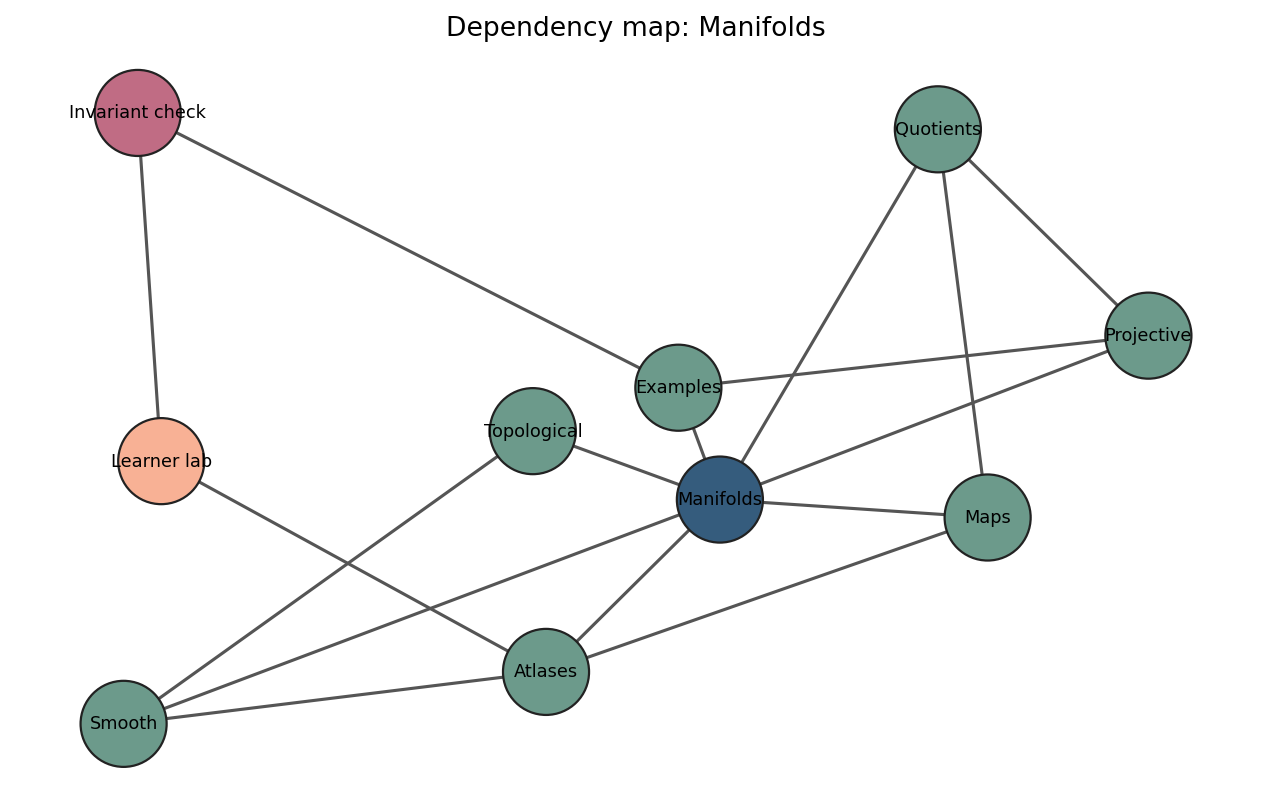

In [2]:
concepts = ["Topological", "Smooth", "Atlases", "Maps", "Quotients", "Projective", "Examples"]
G = nx.DiGraph()
G.add_node(UNIT_TITLE, role="source unit")
for idx, concept in enumerate(concepts):
    G.add_node(concept, role="concept")
    G.add_edge(UNIT_TITLE, concept)
    if idx > 0:
        G.add_edge(concepts[idx - 1], concept)
G.add_node("Invariant check", role="validation")
G.add_node("Learner lab", role="experiment")
G.add_edge(concepts[-1], "Invariant check")
G.add_edge(concepts[max(0, len(concepts)//2 - 1)], "Learner lab")
G.add_edge("Learner lab", "Invariant check")

pos = nx.spring_layout(G, seed=len(UNIT_KEY), k=0.9)
fig, ax = plt.subplots(figsize=(10, 6))
colors = [{"source unit": "#355c7d", "concept": "#6c9a8b", "validation": "#c06c84", "experiment": "#f8b195"}.get(G.nodes[n].get("role"), "#dddddd") for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.4, edge_color="#555555")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1500, linewidths=1, edgecolors="#222222")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title(f"Dependency map: {UNIT_TITLE}")
ax.axis("off")
concept_map_path = save_matplotlib(fig, FIGURES / "manifolds-dependency-map.png")
plt.close(fig)
concept_summary_path = save_json({"unit": UNIT_TITLE, "concepts": concepts, "edges": list(G.edges())}, CHECKS / "manifolds-dependency-map.json")
display_artifact(concept_map_path, width=820)


The dependency map is a proof-reading surface: follow arrows from the source-unit question toward the invariant check. A useful inspection habit is to ask which node would fail first if a hypothesis from the chapter were removed. For `Manifolds`, the answer should involve one of the concrete terms in the graph rather than a vague appeal to general theory.


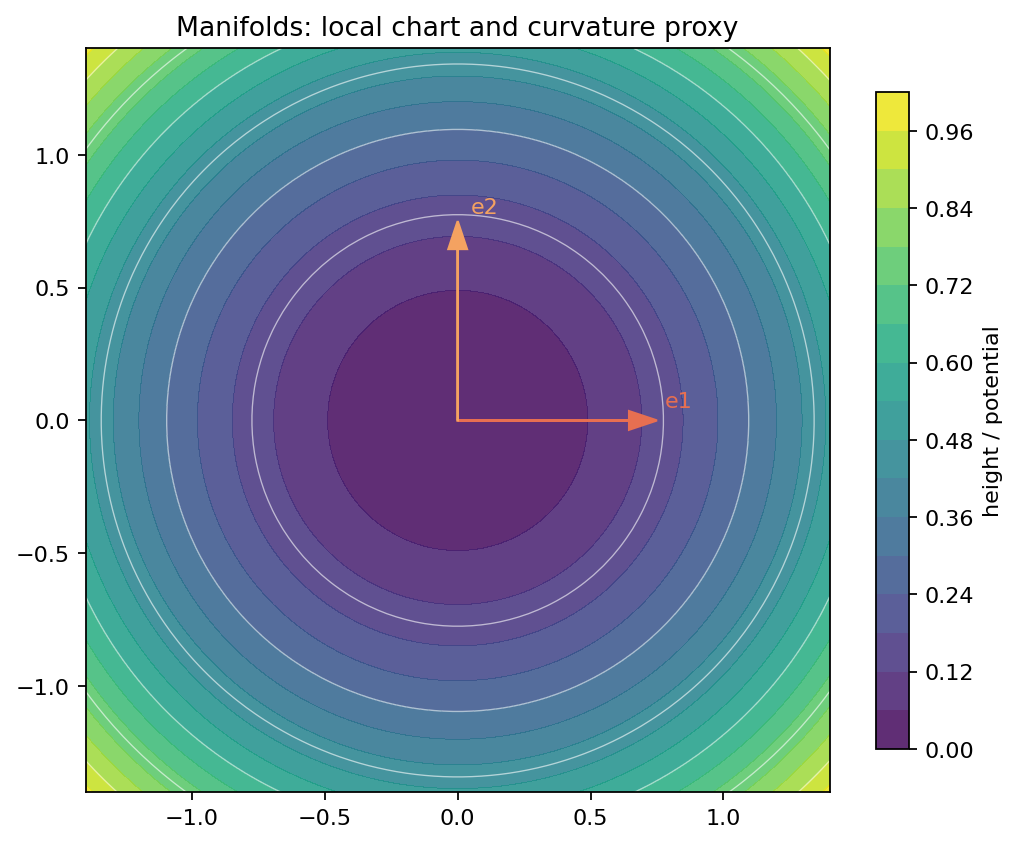

In [3]:
grid = np.linspace(-1.4, 1.4, 80)
X, Y = np.meshgrid(grid, grid)
sign = -1 if (len(UNIT_KEY) % 2) else 1
Z = 0.25 * (X**2 + sign * Y**2)
curvature_proxy = np.gradient(np.gradient(Z, grid, axis=0), grid, axis=0) + np.gradient(np.gradient(Z, grid, axis=1), grid, axis=1)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
levels = ax.contourf(X, Y, Z, levels=16, cmap="viridis", alpha=0.86)
ax.contour(X, Y, Z, levels=8, colors="white", linewidths=0.6, alpha=0.6)
ax.arrow(0, 0, 0.75, 0, head_width=0.07, color="#e76f51", length_includes_head=True)
ax.arrow(0, 0, 0, 0.75, head_width=0.07, color="#f4a261", length_includes_head=True)
ax.text(0.78, 0.05, "e1", color="#e76f51")
ax.text(0.05, 0.78, "e2", color="#f4a261")
ax.set_aspect("equal")
ax.set_title("Manifolds: local chart and curvature proxy")
fig.colorbar(levels, ax=ax, shrink=0.82, label="height / potential")
model_path = save_matplotlib(fig, FIGURES / "manifolds-local-chart-curvature.png")
plt.close(fig)
u, v = sp.symbols("u v")
det_g = sp.factor(sp.Matrix([[1 + u**2, 0], [0, 1 + v**2]]).det())
model_check_path = save_json({"unit": UNIT_TITLE, "focus": "Topological and smooth manifolds, atlases, smooth maps, quotients, and projective examples.", "curvature_proxy_min": float(np.min(curvature_proxy)), "curvature_proxy_max": float(np.max(curvature_proxy)), "metric_determinant": str(det_g), "metric_positive_at_origin": bool(det_g.subs({u:0, v:0}) > 0)}, CHECKS / "manifolds-local-chart-curvature.json")
display_artifact(model_path, width=720)


## Applied Lab

Use the model above as a controlled experiment. Change one numerical parameter, one graph edge, or one symbolic expression, then rerun the visual. The goal is not to make a more complicated picture; it is to see which part of `Manifolds` is stable under perturbation and which part depends on an exact hypothesis.

Suggested lab prompts:

- Identify the smallest displayed object that carries the key invariant.
- Modify the object so the final JSON check changes sign, rank, residual, or combinatorial count.
- Explain in one sentence which theorem move or definition from the source span the change corresponds to.


In [4]:
x, y, t = sp.symbols("x y t", real=True)
matrix = sp.Matrix([[1, x, x**2], [1, y, y**2], [1, t, t**2]])
vandermonde = sp.factor(matrix.det())
residual_at_repeat = sp.simplify(vandermonde.subs(t, x))
numeric_vector = np.array([len(c) for c in concepts], dtype=float)
normalized = numeric_vector / numeric_vector.sum()
entropy = float(-(normalized * np.log(normalized)).sum())
invariant_report = {
    "unit": UNIT_TITLE,
    "formulas": ["d(f\\circ g)=df\\circ dg", "[X,Y]=XY-YX", "d^2=0"],
    "concept_count": len(concepts),
    "vandermonde_factor": str(vandermonde),
    "residual_when_two_parameters_coincide": str(residual_at_repeat),
    "concept_length_entropy": entropy,
    "checks": {
        "dependency_graph_is_weakly_connected": nx.is_weakly_connected(G),
        "vandermonde_vanishes_on_collision": residual_at_repeat == 0,
        "entropy_positive": entropy > 0,
    },
}
invariant_path = save_json(invariant_report, CHECKS / "manifolds-invariants.json")
print(json.dumps(invariant_report, indent=2))


{
  "unit": "Manifolds",
  "formulas": [
    "d(f\\circ g)=df\\circ dg",
    "[X,Y]=XY-YX",
    "d^2=0"
  ],
  "concept_count": 7,
  "vandermonde_factor": "-(-t + x)*(-t + y)*(x - y)",
  "residual_when_two_parameters_coincide": "0",
  "concept_length_entropy": 1.9031448622611569,
  "checks": {
    "dependency_graph_is_weakly_connected": true,
    "vandermonde_vanishes_on_collision": true,
    "entropy_positive": true
  }
}


## Chapter-Specific Inspection Notes

This unit's source span is organized around **Manifolds**, not merely around the general subject of An Introduction to Manifolds. A useful first pass is to track how Topological, Smooth, and Atlases enter the discussion, then ask which construction turns those ingredients into a checkable object. In this notebook the dependency graph is the reading map, while the model diagram is the smallest computational witness for the chapter's main behavior.

The source focus for this unit is: Topological and smooth manifolds, atlases, smooth maps, quotients, and projective examples. The notebook translates that focus into explicit data so the learner can inspect assumptions instead of memorizing labels. When a theorem in the chapter depends on a hypothesis, the corresponding experiment should have a visible failure mode: a degenerate determinant, a broken boundary relation, a changed orientation sign, a disconnected dependency graph, a nonpositive metric determinant, or a changed combinatorial count.

For review, compare three layers. The **formal layer** records formulas and symbolic residuals. The **visual layer** shows a graph, complex, surface, knot, or point configuration. The **lab layer** asks the reader to perturb one ingredient and predict which invariant changes. A strong reading of this notebook means being able to move between those layers without needing the source PDF open.


## Takeaways

- `Manifolds` is best read as a network of constructions and checks, not as a list of isolated definitions.
- The formulas `d(f\circ g)=df\circ dg`, `[X,Y]=XY-YX`, `d^2=0` give a compact way to test whether the examples obey the same invariant grammar as the source span.
- The displayed artifacts are intentionally small. Their job is to make the key structure inspectable, not to reproduce textbook figures.
- A reader should now be able to explain what the unit studies, name a representative model, and point to at least one executable check that would fail for a badly chosen example.


In [5]:
# final_sanity
final_sanity_paths = [concept_map_path, concept_summary_path, model_path, model_check_path, invariant_path]
assert_artifacts(final_sanity_paths, min_bytes=40)
assert invariant_report["checks"]["dependency_graph_is_weakly_connected"]
assert invariant_report["checks"]["vandermonde_vanishes_on_collision"]
print(f"final_sanity passed for {UNIT_TITLE} with {len(final_sanity_paths)} artifacts")


final_sanity passed for Manifolds with 5 artifacts
